In [1]:
## Importando bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt

from starforge.cosmology import LCDMModel  
from starforge.cosmology import CosmologicalParameters
from starforge.structures import Perturbations


In [2]:
## Definindo parâmetros cosmológicos (exemplo Planck 2018)
params = CosmologicalParameters(
    omegam=0.24,
    omegab=0.04,
    omegal=0.73,
    h=0.7   
)

lcdm = LCDMModel(params)

pert = Perturbations(lcdm)


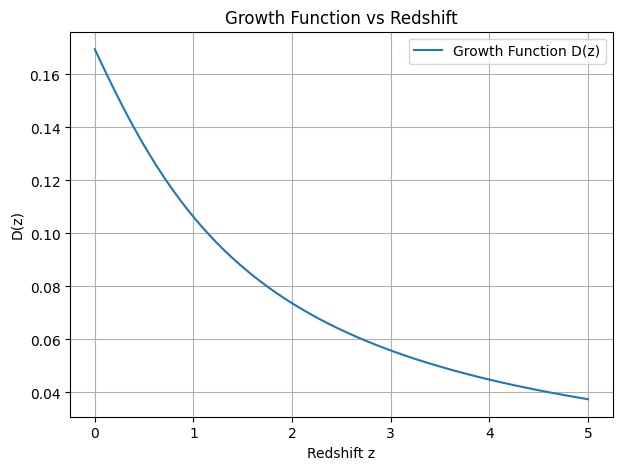

In [3]:
## Teste 1: Função de crescimento em função do redshift
z = np.linspace(0, 5, 200)
growth = [pert.growth_function(zi) for zi in z]

plt.figure(figsize=(7,5))
plt.plot(z, growth, label="Growth Function D(z)")
plt.xlabel("Redshift z")
plt.ylabel("D(z)")
plt.title("Growth Function vs Redshift")
plt.legend()
plt.grid()
plt.show()


In [4]:

# assume perturbations.growth_function exists (novo) and old_growth(z) se houver versão antiga
z = np.linspace(0.0, 6.0, 601)   # passo 0.01 para resolução alta
g = np.array([pert.growth_function(zi) for zi in z])

# differences, relative differences and derivative
rel_diff = np.abs(np.gradient(g, z) / (g + 1e-30))
dg_dz = np.gradient(g, z)
d2g_dz2 = np.gradient(dg_dz, z)

# inspect statistics around z~2
mask = (z > 1.5) & (z < 2.5)
print("growth range near z=2:", g[mask].min(), g[mask].max())
print("max abs derivative near z=2:", np.max(np.abs(dg_dz[mask])))
print("max rel derivative near z=2:", np.max(rel_diff[mask]))
print("max second derivative near z=2:", np.max(np.abs(d2g_dz2[mask])))

growth range near z=2: 0.06372628636814626 0.08694927898170192
max abs derivative near z=2: 0.03163652725965882
max rel derivative near z=2: 0.3638503692056674
max second derivative near z=2: 0.020958708320462094


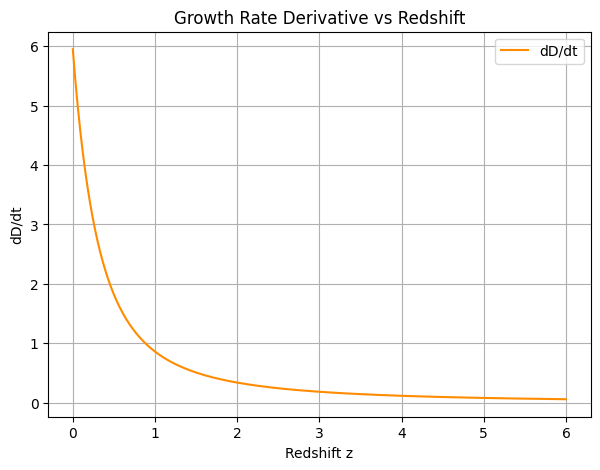

In [5]:
## Teste 2: Derivada temporal da função de crescimento
dgrowth = [pert.dgrowth_dt(zi) for zi in z]

plt.figure(figsize=(7,5))
plt.plot(z, dgrowth, color="darkorange", label="dD/dt")
plt.xlabel("Redshift z")
plt.ylabel("dD/dt")
plt.title("Growth Rate Derivative vs Redshift")
plt.legend()
plt.grid()
plt.show()


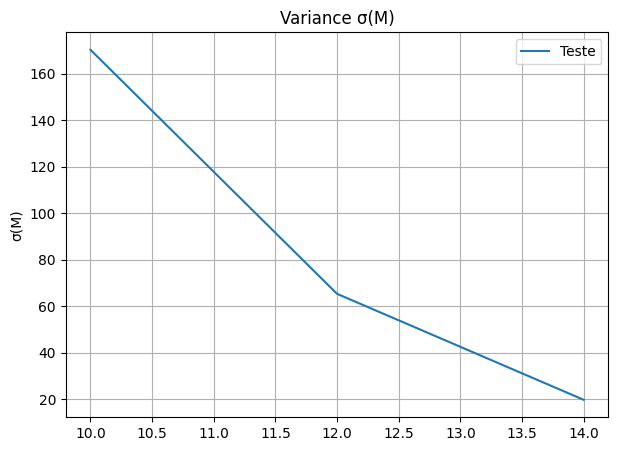

In [6]:
## Teste 3: Variância σ(M, z) para diferentes massas
M_values = np.array([1e10, 1e12, 1e14]) # massas em unidades arbitrárias

plt.figure(figsize=(7,5))
km, sigma = pert.sigma(M_values) 
plt.plot(km, sigma, label=f"Teste")
    
plt.ylabel("σ(M)")
plt.title("Variance σ(M)")
plt.legend()
plt.grid()
plt.show()
